In [33]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/TISC Historical Data (1).csv")

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      5000 non-null   object 
 1   Price     5000 non-null   float64
 2   Open      5000 non-null   float64
 3   High      5000 non-null   float64
 4   Low       5000 non-null   float64
 5   Vol.      5000 non-null   object 
 6   Change %  5000 non-null   object 
dtypes: float64(4), object(3)
memory usage: 273.6+ KB


In [35]:
df.isnull().sum()

,0
Date,0
Price,0
Open,0
High,0
Low,0
Vol.,0
Change %,0


In [36]:
# remove date , price , vol , change
df.drop(['Date','Price','Vol.','Change %'],axis=1,inplace=True)

# Reorder columns to move 'High' to the end
cols = list(df.columns)
cols.remove('High')
df = df[cols + ['High']]

In [37]:
# Reverse the order of the DataFrame
df = df.iloc[::-1].reset_index(drop=True)

In [38]:
df

,Open,Low,High
0,7.50,7.41,7.55
1,7.50,7.44,7.58
2,7.49,7.40,7.55
3,7.45,7.45,7.71
4,7.71,7.65,7.79
...,...,...,...
4995,113.50,113.00,117.00
4996,117.40,116.30,118.90
4997,118.45,116.56,119.20
4998,118.11,116.28,119.10


<Axes: >

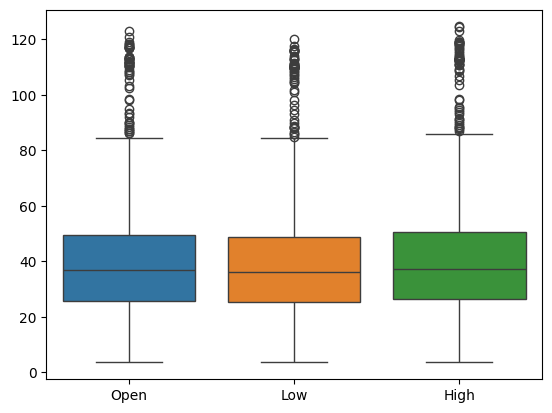

In [39]:
import seaborn as sns
sns.boxplot(df)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    5000 non-null   float64
 1   Low     5000 non-null   float64
 2   High    5000 non-null   float64
dtypes: float64(3)
memory usage: 117.3 KB


In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [43]:
x=df.drop('High',axis=1)
y=df['High']
scaler=RobustScaler()
x=scaler.fit_transform(x)

In [44]:
# scaling for financial data use standard scaler target is high
from sklearn.preprocessing import StandardScaler
# now use catboost
from sklearn.ensemble import RandomForestRegressor
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
cb=RandomForestRegressor(n_estimators= 400, min_samples_split= 2, min_samples_leaf= 4, max_depth= 30)
cb.fit(x_train,y_train)
y_pred=cb.predict(x_test)
print(mean_squared_error(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

0.5073622164278365
0.40682103475450093
0.9986502092657924


In [46]:
y_test,y_pred

(1501    49.67
 2586    36.67
 2653    33.50
 1055    30.01
 705     21.20
         ...  
 4711    28.40
 2313    47.34
 3214    36.56
 2732    40.01
 1926    16.24
 Name: High, Length: 1000, dtype: float64,
 array([ 48.46589589,  36.84715898,  33.12460972,  29.49036339,
         21.15274857,   4.34084779,  14.40310486,  57.16630662,
         57.27435242,  64.07823371,  57.74827299,   6.06507245,
         28.08007412,  19.88738072,  24.66243833,  23.68165786,
         31.20945144,  44.74915025,  75.0544604 ,  32.8545793 ,
         31.2507218 ,  18.44151594,  27.57125246,  20.98836954,
         36.39475253,   7.8088098 ,  61.67261015,   6.33139601,
         27.23190081,   7.27913877,  18.45011494,   7.42618917,
         45.16942765,  66.01255599,  81.80123964,  51.12593876,
         22.70414301,  61.54583895, 114.17558195,  50.12308457,
         21.92395655,  64.42026364,   6.10455057,   4.7156134 ,
         23.6785305 ,  42.42360402,  33.4725395 ,  50.53818954,
         34.58477392,  4

In [47]:
import pickle

# Save the scaler
with open('robust_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save the best model
with open('randomforest_model.pkl', 'wb') as f:
    pickle.dump(cb, f)

print("Scaler and model saved successfully.")

Scaler and model saved successfully.


In [14]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for randomized search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8]
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42),
                                   param_distributions=param_dist,
                                   n_iter=100, # Number of iterations
                                   cv=3,
                                   n_jobs=-1,
                                   scoring='neg_mean_squared_error',
                                   random_state=42)

# Fit the RandomizedSearchCV object to the training data
random_search.fit(x_train, y_train)

# Get the best hyperparameters and the best model
best_params_random = random_search.best_params_
best_model_random = random_search.best_estimator_

print("Best Hyperparameters (Randomized Search):", best_params_random)

# Evaluate the best model on the test data
y_pred_random = best_model_random.predict(x_test)
print("Mean Squared Error with tuned model (Randomized Search):", mean_squared_error(y_test, y_pred_random))
print("Mean Absolute Error with tuned model (Randomized Search):", mean_absolute_error(y_test, y_pred_random))
print("R-squared with tuned model (Randomized Search):", r2_score(y_test, y_pred_random))

Best Hyperparameters (Randomized Search): {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30}
Mean Squared Error with tuned model (Randomized Search): 0.5032293645814688
Mean Absolute Error with tuned model (Randomized Search): 0.4067173037791626
R-squared with tuned model (Randomized Search): 0.9986612043398193


**Testing my model**

In [49]:
import pickle
import numpy as np
import pandas as pd

# Define paths to the saved scaler and model
scaler_path = 'robust_scaler.pkl'
model_path = 'randomforest_model.pkl'

# Load the scaler
try:
    with open(scaler_path, 'rb') as f:
        scaler = pickle.load(f)
except FileNotFoundError:
    print(f"Error: Scaler file not found at {scaler_path}")
    scaler = None

# Load the model
try:
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
except FileNotFoundError:
    print(f"Error: Model file not found at {model_path}")
    model = None

if scaler is not None and model is not None:
    # Get input from the user
    try:
        open_price = float(input("Enter the 'Open' price: "))
        low_price = float(input("Enter the 'Low' price: "))
    except ValueError:
        print("Invalid input. Please enter numeric values.")
        open_price = None
        low_price = None

    if open_price is not None and low_price is not None:
        # Create the input data DataFrame with column names
        input_data = pd.DataFrame([[open_price, low_price]], columns=['Open', 'Low'])

        # Scale the input data
        scaled_input_data = scaler.transform(input_data)

        # Make predictions
        predictions = model.predict(scaled_input_data)

        print(f"Predicted 'High' price: {predictions[0]}")

Enter the 'Open' price: 120.23
Enter the 'Low' price: 118.76
Predicted 'High' price: 120.96224630634069
